In [ ]:
#Importações
from keras.models import Sequential
from keras.layers import Dense
from keras.wrappers.scikit_learn import KerasClassifier
from keras import optimizers
from os import listdir
from os import mkdir
from shutil import move
from keras.preprocessing.image import load_img
from keras.preprocessing.image import img_to_array
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.preprocessing.image import ImageDataGenerator
from matplotlib import pyplot
from random import seed
from keras.models import Model

In [ ]:
os.mkdir("/test")
os.mkdir("/train")
if(file.startswith()):
  shutil.move(file, pastaObjetivo)

'/content'

In [ ]:
pasta = ""
fotos = []
numeroFoto = []

In [ ]:
#Adicionando fotos de treinamento de gatos na lista
for file in os.listdir(pasta):
  numero=None
  if(file.startswith(0)):
    numero=0
  elif(file.startswith(1)):
    numero=1
  elif(file.startswith(2)):
    numero=2
  elif(file.startswith(3)):
    numero=3
  elif(file.startswith(4)):
    numero=4
  elif(file.startswith(5)):
    numero=5
  elif(file.startswith(6)):
    numero=6
  elif(file.startswith(7)):
    numero=7
  elif(file.startswith(8)):
    numero=8
  elif(file.startswith(0)):
    numero=9
  foto = load_img(pasta + file, target_size=(28, 28))
  foto = img_to_array(foto)
  fotos.append(foto)
  numeroFoto.append(numero)

In [ ]:
def ModeloTrabalho():
  model = Sequential()
  #Camada convulucional 2d de entrada, imagem 28x28 rgb
  #kernel_size: Um inteiro ou tupla/lista de 2 inteiros, especificando a altura e largura da janela de convolução 2D -> (3,3)
  model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='normal', padding='same', input_shape=(28, 28, 3)))
  model.add(MaxPooling2D((2, 2)))
  #Achata a entrada. Não afeta o tamanho do lote.
  model.add(Flatten())
  model.add(Dense(64, activation='relu', kernel_initializer='normal'))
  model.add(Dense(32, activation='relu', kernel_initializer='normal'))
  model.add(Dense(16, activation='relu', kernel_initializer='normal'))
  model.add(Dense(8, activation='relu', kernel_initializer='normal'))
  model.add(Dense(1, activation='softmax'))
  model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
  return model

In [ ]:
#Gráfico sobre perda acuracia
#dei copy e foda-se, da pra entender
def diagnostico(history):
    # loss
    pyplot.subplot(211)
    pyplot.title('Perda')
    pyplot.plot(history.history['loss'], color='blue', label='Treino')
    pyplot.plot(history.history['val_loss'], color='orange', label='Validacao')
    # accuracy
    print("\n")
    pyplot.subplot(212)
    pyplot.title('Precisão')
    pyplot.plot(history.history['accuracy'], color='blue', label='Treino')
    pyplot.plot(history.history['val_accuracy'], color='orange', label='Validacao')
    # mostrar plot
    pyplot.legend()
    pyplot.show()

In [ ]:
#Criando ambiente de execução
def modeloExec():
  seed(1)
  model = criarModelo2()
  datagen = ImageDataGenerator(rescale=1.0/255.0)
  treine=datagen.flow_from_directory(pastaTreino, class_mode='binary', batch_size=2, target_size=(28, 28))
  valide=datagen.flow_from_directory(pastaValidacao, class_mode='binary', batch_size=2, target_size=(28, 28))
  historico = model.fit(treine, steps_per_epoch=len(treine), validation_data=valide, validation_steps=len(valide), epochs=5, verbose=2)
  diagnostico(historico)

Found 6 images belonging to 2 classes.
Found 6 images belonging to 2 classes.
Epoch 1/5
3/3 - 6s - loss: 10.0318 - accuracy: 0.3333 - val_loss: 1.0182 - val_accuracy: 0.6667
Epoch 2/5
3/3 - 4s - loss: 1.3778 - accuracy: 0.6667 - val_loss: 1.5008 - val_accuracy: 0.5000
Epoch 3/5
3/3 - 5s - loss: 0.8999 - accuracy: 0.6667 - val_loss: 0.7528 - val_accuracy: 0.5000
Epoch 4/5
3/3 - 5s - loss: 0.6846 - accuracy: 0.5000 - val_loss: 0.7074 - val_accuracy: 0.5000
Epoch 5/5
3/3 - 5s - loss: 0.5672 - accuracy: 0.6667 - val_loss: 0.6864 - val_accuracy: 0.3333
INFO:tensorflow:Assets written to: modelo.pkl/assets




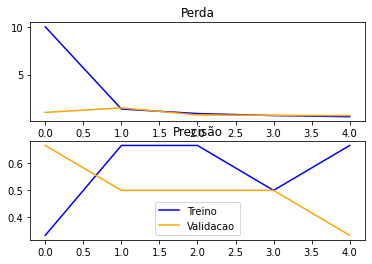

In [ ]:
#Execultando aprendizado do modelo
modeloExec()

In [ ]:
#Pasta de validação
pasta1="/content/drive/MyDrive/ML02/valid/cat/"
pasta2="/content/drive/MyDrive/ML02/valid/dog/"

#Carregando imagem, transformando em 200x200
def load_image(filename,folder):
    img = load_img(folder+filename, target_size=(200, 200))
    img = img_to_array(img)
    # redimensionar imagem
    img = img.reshape(1, 200, 200, 3)
    img = img.astype('float32')
    return img

#Prevendo uma imagem especifica
def prever(img,pasta):
  #Modelo
  modelo=criarModelo2()
  #Adaptando imagem
  img=load_image(img,pasta)
  #Adaptando resultado
  resultado = modelo.predict(img)
  if(resultado>=0.5):
    return "Gato"
  else:
    return "Dog"

In [ ]:
prever("gato4.jpg","/content/drive/MyDrive/ML02/valid/cat/")

'Gato'

In [ ]:
prever("dog4.jpg","/content/drive/MyDrive/ML02/valid/dog/")

'Dog'

In [ ]:
prever("gato6.jpg",pasta1)

'Dog'

In [ ]:
#Prevendo várias imagens em todas as classes
resultados=list()
pastas=[pasta1,pasta2]
for x in pastas:
  for resultado in listdir(x):
    resposta = prever(resultado,x)
    resultados.append(resposta)
print(resultados)

['Dog', 'Gato', 'Gato', 'Gato', 'Gato', 'Dog']


In [ ]:
# Modelo ta prevendo errado
# Humanos são mais inteligentes
# Resultado correto na ordem das pastas (pasta1,pasta2):
# Gato,Gato,Gato,Dog,Dog,Dog